# Click-Through Rate (CTR) Prediction

## Phase 1: Data Loading & Initial Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('Ad_click_prediction_train.csv', parse_dates=['DateTime'])

# 2. Dataset Dimensions
print(f"Dataset Shape: {df.shape}")

# 3. Check Column Types and Missing Values
print("\n--- Column Info & Null Values ---")
print(df.info())

# 4. Target Variable Distribution (The CTR)
ctr_stats = df['is_click'].value_counts(normalize=True) * 100
print("\n--- Target Distribution ---")
print(f"No Click (0): {ctr_stats[0]:.2f}%")
print(f"Click (1): {ctr_stats[1]:.2f}%")

Dataset Shape: (463291, 15)

--- Column Info & Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   session_id              463291 non-null  int64         
 1   DateTime                463291 non-null  datetime64[ns]
 2   user_id                 463291 non-null  int64         
 3   product                 463291 non-null  object        
 4   campaign_id             463291 non-null  int64         
 5   webpage_id              463291 non-null  int64         
 6   product_category_1      463291 non-null  int64         
 7   product_category_2      97437 non-null   float64       
 8   user_group_id           445048 non-null  float64       
 9   gender                  445048 non-null  object        
 10  age_level               445048 non-null  float64       
 11  user_depth              4450

## Phase 2: Exploratory Data Analysis (EDA)

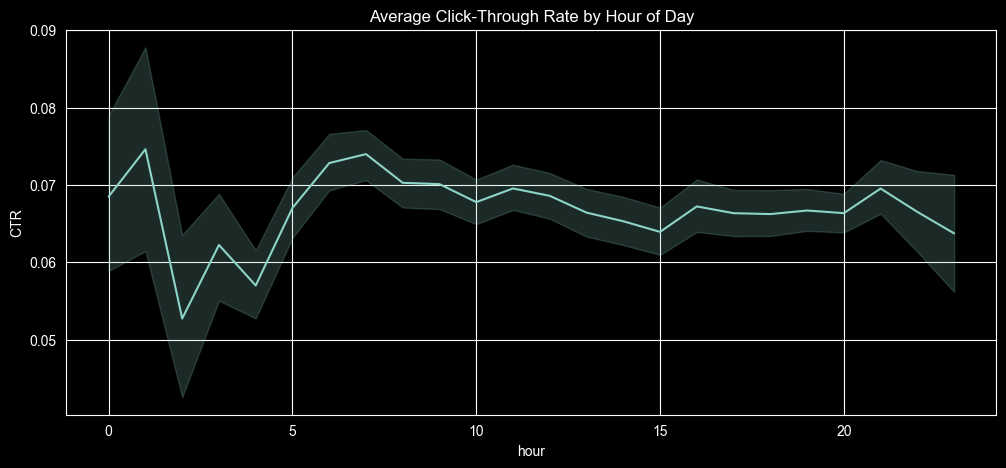

In [2]:
# Extracting basic time features for EDA
df['hour'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek # 0=Monday

# Visualizing Clicks by Hour
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='is_click', estimator=np.mean)
plt.title('Average Click-Through Rate by Hour of Day')
plt.ylabel('CTR')
plt.grid(True)
plt.show()

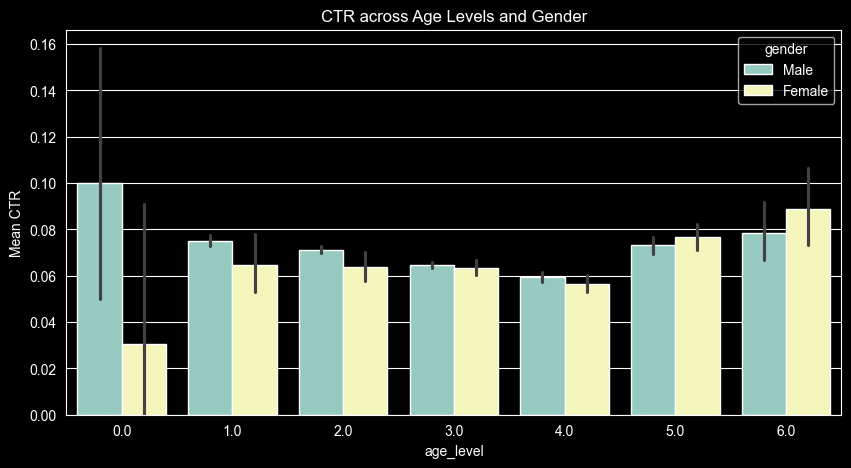

In [3]:
# CTR by Age Level
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='age_level', y='is_click', hue='gender')
plt.title('CTR across Age Levels and Gender')
plt.ylabel('Mean CTR')
plt.show()

In [ ]:
# CTR by Age Level
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='age_level', y='is_click', hue='gender')
plt.title('CTR across Age Levels and Gender')
plt.ylabel('Mean CTR')
plt.show()

## Phase 3: Feature Engineering

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_ctr_data(df):
    # --- 1. DateTime Features ---
    print("Extracting temporal features...")
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df['hour'] = df['DateTime'].dt.hour
    df['day_of_week'] = df['DateTime'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # --- 2. Interaction Features ---
    print("Creating interaction features...")
    # Creating string combinations of key IDs
    df['user_product_interaction'] = df['user_id'].astype(str) + "_" + df['product'].astype(str)
    df['campaign_webpage'] = df['campaign_id'].astype(str) + "_" + df['webpage_id'].astype(str)
    df['gender_age'] = df['gender'].astype(str) + "_" + df['age_level'].astype(str)

    # --- 3. Historical Aggregations (The Fix) ---
    print("Calculating historical CTR stats...")

    # User Stats
    user_stats = df.groupby('user_id')['is_click'].agg(
        user_total_views='count',
        user_ctr='mean'
    ).reset_index()

    # Product Stats
    product_stats = df.groupby('product')['is_click'].agg(
        product_views='count',
        product_ctr='mean'
    ).reset_index()

    # Merge stats back to main dataframe
    df = df.merge(user_stats, on='user_id', how='left')
    df = df.merge(product_stats, on='product', how='left')

    # Fill NaNs (Cold Start Fix)
    # If a user/product is new, we give them the global average CTR
    global_mean_ctr = df['is_click'].mean()
    df['user_ctr'] = df['user_ctr'].fillna(global_mean_ctr)
    df['product_ctr'] = df['product_ctr'].fillna(global_mean_ctr)
    df['user_total_views'] = df['user_total_views'].fillna(0)
    df['product_views'] = df['product_views'].fillna(0)

    # --- 4. Categorical Encoding ---
    print("Encoding categorical variables...")
    cat_cols = [
        'product', 'campaign_id', 'webpage_id', 'product_category_1',
        'product_category_2', 'gender', 'user_group_id', 'var_1',
        'user_product_interaction', 'campaign_webpage', 'gender_age'
    ]

    le = LabelEncoder()
    for col in cat_cols:
        # Fill missing categorical values with 'Unknown' before encoding
        df[col] = df[col].fillna('Unknown').astype(str)
        df[col] = le.fit_transform(df[col])

    # --- 5. Cleanup ---
    # Drop IDs and Raw DateTime (keep engineered versions)
    drop_cols = ['DateTime', 'session_id', 'user_id']
    df_final = df.drop(columns=[c for c in drop_cols if c in df.columns])

    print("Preprocessing complete!")
    return df_final

# Execute
df_clean = preprocess_ctr_data(df)


Extracting temporal features...
Creating interaction features...
Calculating historical CTR stats...


MergeError: Passing 'suffixes' which cause duplicate columns {'user_ctr_x', 'user_total_views_x'} is not allowed.